In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
df=pd.read_csv('Electric_Vehicle_Population_Data (1).csv')
df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,1N4AZ0CP6D,King,Kirkland,WA,98034.0,2013,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,75.0,1.0,154635729,POINT (-122.22901 47.72201),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
1,5YJ3E1EC8L,Kitsap,Bainbridge Island,WA,98110.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,308.0,23.0,107518645,POINT (-122.521 47.62759),PUGET SOUND ENERGY INC,5.303509e+10
2,5YJ3E1EBXJ,King,Seattle,WA,98144.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,37.0,474808813,POINT (-122.30866 47.57874),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,ZFAFFAC45R,Thurston,Yelm,WA,98597.0,2024,FIAT,500E,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,2.0,273658514,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,5.306701e+10
4,5YJYGDEE3L,King,Kent,WA,98030.0,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291.0,47.0,109579900,POINT (-122.19975 47.37483),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191825 entries, 0 to 191824
Data columns (total 16 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         191825 non-null  object 
 1   County                                             191822 non-null  object 
 2   City                                               191822 non-null  object 
 3   State                                              191825 non-null  object 
 4   Postal Code                                        191822 non-null  float64
 5   Model Year                                         191825 non-null  int64  
 6   Make                                               191825 non-null  object 
 7   Model                                              191825 non-null  object 
 8   Electric Vehicle Type                              191825 non-null  object

In [24]:
df.isnull().sum()

,0
VIN (1-10),0
County,3
City,3
State,0
Postal Code,3
Model Year,0
Make,0
Model,0
Electric Vehicle Type,0
Clean Alternative Fuel Vehicle (CAFV) Eligibility,0


# data cleaning
 the dataset was checked for missing values and duplicate records.
 ## missing values
 Missing values were found in some colums and handled using mean values.
 ## duplicate records
 Duplicate rows were identified and remove from the dataset
 ## Observation
 the dataset become clnear and more suitable for analysis.

In [25]:
df.isnull().sum()

,0
VIN (1-10),0
County,3
City,3
State,0
Postal Code,3
Model Year,0
Make,0
Model,0
Electric Vehicle Type,0
Clean Alternative Fuel Vehicle (CAFV) Eligibility,0


# Missing value Analysis
the data set was checked for missing values using the insull() function.

some columns contained missing values which can affect analysis and prediction accuracy.

In [26]:
df['Electric Range']= df['Electric Range'] . fillna(df['Electric Range'] .mean())
df['Electric Range'].isnull().sum()

np.int64(0)

## Handling Missing Values
Missing values in the Electric range column were replaced using  the mean value of  the column .

In [27]:
df .duplicated().sum()

np.int64(0)

## Duplicate Records
the datset  was  checked  for duplicate   records  to avoid  repeated  data  during  analysis

In [28]:
df .drop_duplicates(inplace=True)
print("duplicates removed successfully")

duplicates removed successfully


## Removing Duplicates Records
duplicate records were removed from the dataset to improve data quality and ensure accurate analysis.


In [29]:
df['Make'].value_counts().head()

,count
Make,
TESLA,78036
CHEVROLET,12932
NISSAN,11346
FORD,9831
KIA,9619


# Top EV Manufactures
the  dataset  was  analyzed  to  identify  the  most  comman  electric  vehicle  manufactures.

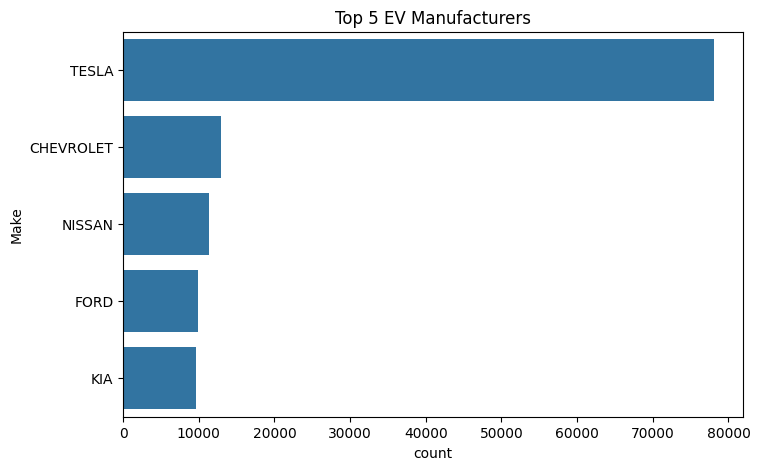

In [30]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,y='Make',order=df['Make'].value_counts().index[:5])
plt.title('Top 5 EV Manufacturers')
plt.show()

# Observation
  Tesla is one of the most comman electric vechile manufacturers in the dataset.
  
  the ghrap shows the top 5 EV companies based on vehical registration

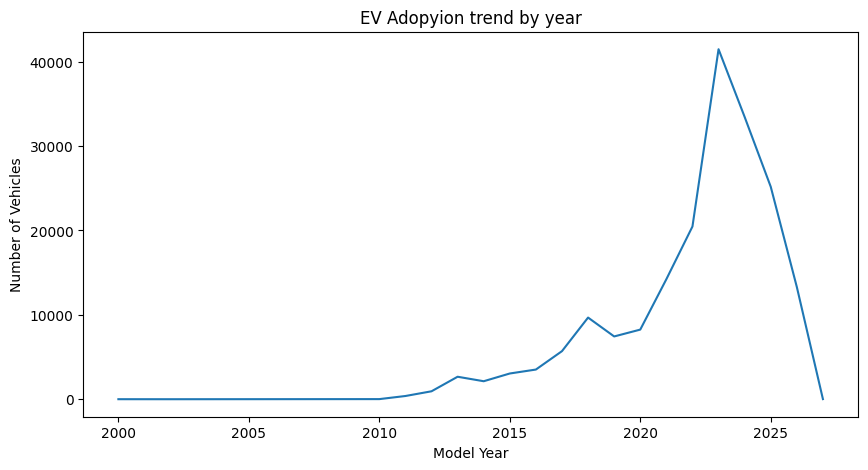

In [31]:
year_counts=df['Model Year'].value_counts().sort_index()
plt.figure(figsize=(10,5))
year_counts.plot(kind='line')
plt.title("EV Adopyion trend by year")
plt.xlabel("Model Year")
plt.ylabel("Number of Vehicles")
plt.show()

# EV Adoption Trend

The graph shows that Electric Vehicle adoption has increased significantly over recent years.

This indicates growing interest in sustainable transportation and clean energy vehicles.

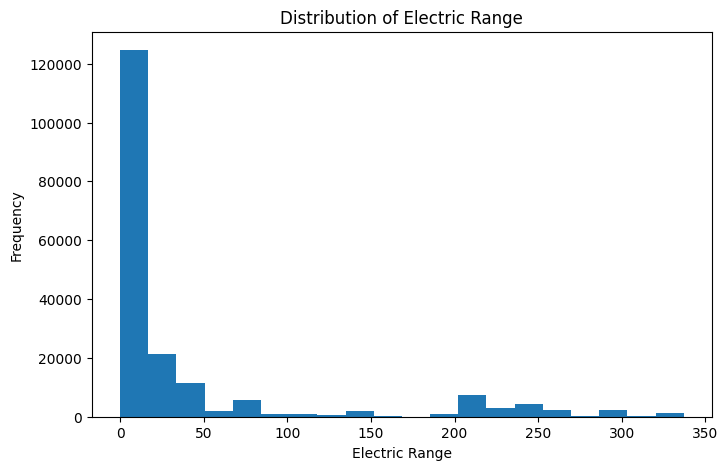

In [32]:
plt.figure(figsize=(8,5))

plt.hist(df['Electric Range'], bins=20)

plt.title("Distribution of Electric Range")
plt.xlabel("Electric Range")
plt.ylabel("Frequency")

plt.show()

# Electric Range Distribution

The histogram shows the distribution of electric vehicle ranges in the dataset.

Most vehicles fall within a moderate electric range category, while fewer vehicles have extremely high ranges.

In [33]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [34]:
le = LabelEncoder()

df['Make_Encoded'] = le.fit_transform(df['Make'])

df[['Make', 'Make_Encoded']].head()

,Make,Make_Encoded
0,NISSAN,31
1,TESLA,39
2,TESLA,39
3,FIAT,11
4,TESLA,39


In [35]:
X = df[['Model Year', 'Make_Encoded']]

y = df['Electric Range']

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [37]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [38]:
predictions = model.predict(X_test)

predictions[:5]

array([ 30.60995116, 102.17544364, 143.07266656,  30.60995116,
         4.55581168])

In [39]:
print(r2_score(y_test, predictions))

0.3069783473597002


# Linear Regression Model

A Linear Regression model was created to predict Electric Range using Model Year and Manufacturer information.

The model performance was evaluated using the R² score.

# Conclusion

This project analyzed Electric Vehicle population data using Python.

The dataset was cleaned and explored using various data analysis techniques.

Visualizations showed that EV adoption has increased significantly over recent years.

Tesla is one of the most dominant EV manufacturers in the dataset.

A Linear Regression model was also created to predict Electric Range using vehicle information.

This project demonstrates the importance of data analytics and machine learning in understanding transportation trends.